In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
# KGAT_343d2087ca427fda3898cfc20040e88a
# KGAT_f747e6584833916572f45d011da5fc7f
import kagglehub
kagglehub.login()


Kaggle credentials set.


In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

ducpham8504_brats2023_preprocessed_v0_path = kagglehub.dataset_download('ducpham8504/brats2023-preprocessed-v0')
# ducpham8504_brats2023_preprocessed_v1_path = kagglehub.dataset_download('ducpham8504/brats2023-preprocessed-v1')
# ducpham8504_brats2023_preprocessed_v3_path = kagglehub.dataset_download('ducpham8504/brats2023-preprocessed-v3')
# ducpham8504_brats2023_preprocessed_v4_path = kagglehub.dataset_download('ducpham8504/brats2023-preprocessed-v4')
ducpham8504_brats2023_validation_path = kagglehub.dataset_download('ducpham8504/brats2023-validation')

print('Data source import complete.')


Using Colab cache for faster access to the 'brats2023-preprocessed-v0' dataset.
Using Colab cache for faster access to the 'brats2023-validation' dataset.
Data source import complete.


In [3]:
import torch
print("Số GPU khả dụng:", torch.cuda.device_count())  # Nên in ra 2
!nvidia-smi  # Xem VRAM usage, cả 2 GPU phải hiện

Số GPU khả dụng: 1
Tue Feb  3 13:34:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------------

In [ ]:
# !pip install torchinfo -q
# !pip install segmentation-models-pytorch-3d -q
# !pip install livelossplot -q
# !pip install torchmetrics -q
# !pip install tensorboard -q
# # !pip install accelerate -q
# !pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu121
# !pip uninstall -y mamba-ssm causal-conv1d
# !pip install causal-conv1d==1.4.0
# !pip install mamba-ssm==2.2.2

# 1. Cài đặt Torch core trước (quan trọng nhất)
!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu121
!pip install transformers==4.36.0
# 2. Cài đặt các thư viện đặc thù yêu cầu compile C++ / CUDA
!pip uninstall -y mamba-ssm causal-conv1d
!pip install causal-conv1d==1.4.0 --no-cache-dir
!pip install mamba-ssm==2.2.2 --no-cache-dir

# 3. Cài đặt các thư viện tiện ích còn lại
# !pip install nibabel torchinfo livelossplot torchmetrics tensorboard segmentation-models-pytorch-3d -q
!pip install nibabel torchmetrics segmentation-models-pytorch-3d -q



In [4]:
import os
import random
from tqdm import tqdm
import nibabel as nib
import glob
import numpy as np
import matplotlib.pyplot as plt

import shutil
import time

from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms
from torch.cuda import amp
from torch.cuda.amp import autocast, GradScaler

from torchmetrics import MeanMetric
from torchmetrics.classification import MulticlassAccuracy

from torch.utils.data import Dataset, DataLoader
# from torch.utils.tensorboard import SummaryWriter
# from torchinfo import summary
import gc

import segmentation_models_pytorch_3d as smp

# from livelossplot import PlotLosses
# from livelossplot.outputs import MatplotlibPlot, ExtremaPrinter

import torch.nn as nn
import torch
from torch.nn import functional as F
from mamba_ssm import Mamba

# from accelerate import Accelerator

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packa

## 2. Data Loader

In [5]:
class BraTs2023Dataset(Dataset):
    def __init__(self,
                 img_list: list[str],
                 mask_list: list[str],
                 is_norm: bool=True
                ):
        super().__init__()
        self.img_list = sorted(img_list)
        self.mask_list = sorted(mask_list)
        if is_norm:
            self.normalizer = transforms.Normalize(mean=[0.5], std=[0.5])

    def _load_image(self, path_image: str) -> np.ndarray:
        image = np.load(path_image)
        return image

    def __len__(self) -> int:
        return len(self.img_list)

    def __getitem__(self, index: int):
        path_img = self.img_list[index]
        path_mask = self.mask_list[index]

        # load ảnh và mask
        image = self._load_image(path_img)
        mask = self._load_image(path_mask)

        # chuyển shape ảnh về dạng [C, D, H, W], shape đang có dạng [H, W, D, C]-> điều này cần thiết cho model
        image = torch.from_numpy(image).permute(3, 2, 0, 1).float()
        mask = torch.from_numpy(mask).permute(3, 2, 0, 1)

        # chuẩn hóa ảnh
        if self.normalizer:
            image = self.normalizer(image)
        return image, mask

In [6]:
train_img_list = []
train_mask_list = []
val_img_list = []
val_mask_list = []


TRAIN_DIR = ducpham8504_brats2023_preprocessed_v0_path
VAL_DIR = ducpham8504_brats2023_validation_path


items = os.listdir(TRAIN_DIR)

image_folder = os.path.join(TRAIN_DIR, items[0])
for image_name in os.listdir(image_folder):
    train_img_list.append(os.path.join(image_folder, image_name)) # append tất cả đường dẫn ảnh vào img_list

mask_folder = os.path.join(TRAIN_DIR, items[1])
for mask_name in os.listdir(mask_folder):
    train_mask_list.append(os.path.join(mask_folder, mask_name)) # append tất cả đường dẫn mask vào img_list


folders = os.listdir(VAL_DIR)
folder_img_dir = os.path.join(VAL_DIR, folders[0])
folder_mask_dir = os.path.join(VAL_DIR, folders[1])

for img_name in os.listdir(folder_img_dir):
    path_img = os.path.join(folder_img_dir, img_name)
    val_img_list.append(path_img)

for mask_name in os.listdir(folder_mask_dir):
    path_mask = os.path.join(folder_mask_dir, mask_name)
    val_mask_list.append(path_mask)


print(len(train_img_list))
print(len(train_mask_list))

print(len(val_img_list))
print(len(val_mask_list))

146
146
85
85


In [8]:
train_dataset = BraTs2023Dataset(train_img_list, train_mask_list)
val_dataset = BraTs2023Dataset(val_img_list, val_mask_list)

print(train_dataset[0][0].shape)
print(train_dataset[0][1].shape)


print(val_dataset[0][0].shape)
print(val_dataset[0][1].shape)

torch.Size([3, 128, 128, 128])
torch.Size([4, 128, 128, 128])
torch.Size([3, 128, 128, 128])
torch.Size([4, 128, 128, 128])


In [ ]:
train_loader = DataLoader(train_dataset, batch_size = 2, shuffle = True, num_workers = 4)
val_loader = DataLoader(val_dataset, batch_size = 2, shuffle = False, num_workers = 4) 
sample = next(iter(train_loader))
image, mask = sample
print(image.shape) # [B, C, D, H, W]
print(mask.shape) # [B, C, D, H, W]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


torch.Size([2, 3, 128, 128, 128])
torch.Size([2, 4, 128, 128, 128])


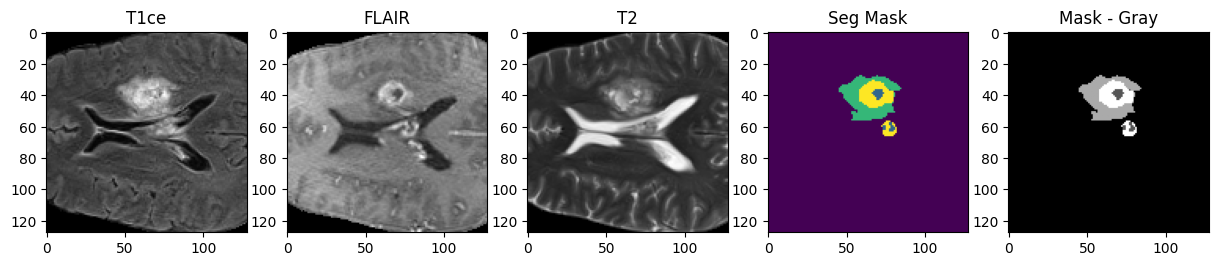

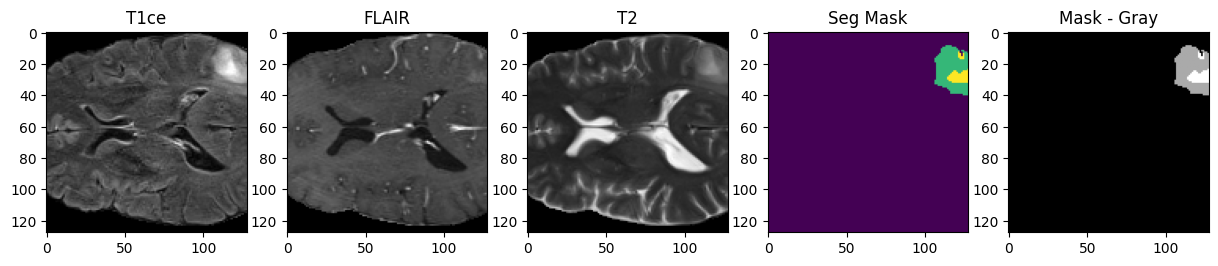

In [10]:
def visualize_slices(images, masks, num_slices=20):
    batch_size = min(images.shape[0], 4)

    masks = torch.argmax(masks, dim=1) #along the channel/class dim

    for i in range(min(num_slices, batch_size)):
        fig,ax = plt.subplots(1,5,figsize = (15,5))

        middle_slice = images.shape[2] // 2
        ax[0].imshow(images[i,0, middle_slice,:,:], cmap = 'gray')
        ax[1].imshow(images[i, 1, middle_slice, : ,:], cmap = 'gray')
        ax[2].imshow(images[i, 2, middle_slice, :, :], cmap = 'gray')
        ax[3].imshow(masks[i, middle_slice, : ,:], cmap = 'viridis')
        ax[4].imshow(masks[i, middle_slice, : ,:], cmap = 'gray')


        ax[0].set_title('T1ce')
        ax[1].set_title('FLAIR')
        ax[2].set_title('T2')
        ax[3].set_title('Seg Mask')
        ax[4].set_title('Mask - Gray')

        plt.show()

visualize_slices(image, mask, num_slices = 20)

## 3. Model CNN + MAMBA

In [11]:
class ConvBlock(nn.Module):
    """Basic 3D convolution block with residual"""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv3d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm3d(out_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.1 if out_channels <= 32 else 0.2 if out_channels <= 128 else 0.3)
        self.conv2 = nn.Conv3d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm3d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv3d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm3d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.dropout(self.relu1(out))
        out += self.shortcut(x)
        out = self.relu2(out)
        return out



class MambaBlock(nn.Module):
    def __init__(self,
                 d_state: int,
                 d_model: int,
                 d_conv: int,
                 expand: int,
                 num_directions: int
                 ):
        super().__init__()

        self.d_model = d_model
        self.num_directions = num_directions

        self.mamba = Mamba(
            d_model,
            d_state,
            d_conv,
            expand
        )

        self.local_conv = nn.Conv3d(
            d_model, d_model, kernel_size=3, padding=1, groups=d_model
        )
        self.norm = nn.LayerNorm(d_model)
        # 3C -> C, caculate on last channel
        self.fusion = nn.Linear(d_model*num_directions, d_model)

    def scan_direction(self, x, direction):
      """
      Flatten 3D volume (B, C, D, H, W) thành sequence 1D theo hướng.
      Returns: sequence (B, seq_len, C), scan_info để unscan sau.
      """

      B, C, D, H, W = x.shape

      if direction == 0: # Axial (x): scan along D (depth slices)
        x = x.permute(0, 2, 3, 4, 1) # [B, D, H, W, C]
        x = x.reshape(B, D, H*W, C) # [B, D, pixels_per_slice, C]
        seg_len_base = D
        pixels_per = H*W

      elif direction == 1: # Sagittal(y): scan along W (left-right)
        x = x.permute(0, 4, 2, 3, 1) # [B, W, D, H, C]
        x = x.reshape(B, W, D*H, C) # [B, W, pixels_per_slice, C]
        seg_len_base = W
        pixels_per = D*H

      elif direction == 2: # Coronal(z): scan along H (top-bottom)
        x = x.permute(0, 3, 2, 4, 1)
        x = x.reshape(B, H, D*W, C)
        seg_len_base = H
        pixels_per = D*W
      # flatten to sequence
      x = x.reshape(B, seg_len_base*pixels_per, C) # [B, L, C]
      scan_info = (B, seg_len_base, pixels_per, C, D, H, W, direction)
      return x, scan_info

    def unscan_direction(self, x, scan_info):
      B, seg_len_base, pixels_per, C, D, H, W, direction = scan_info

      x = x.reshape(B, seg_len_base, pixels_per, C)

      if direction == 0: # Axial
        x = x.reshape(B, D, H, W, C) # [B, D, pixels_per_slice, C] => [B, D, H, W, C]
        x = x.permute(0, 4, 1, 2, 3) # [B, D, H, W, C] => [B, C, D, H, W]

      elif direction == 1: # Sagittal
        x = x.reshape(B, W, D, H, C) # [B, W, pixels_per_slice, C] => [B, W, D, H, C]
        x = x.permute(0, 4, 2, 3, 1) # [B, W, D, H, C] => [B, C, D, H, W]

      elif direction == 2: # Coronal
        x = x.reshape(B, H, D, W, C) # [B, H, pixels_per_slice] => [B, H, D, W, C]
        x = x.permute(0, 4, 2, 1, 3) # [B, H, D, W, C] => [B, C, D, H, W]

      return x

    def bidirectional_mamba(self, x_seq):
      fws = self.mamba(x_seq)
      bwd = self.mamba(torch.flip(x_seq, dims=[1]))
      bwd = torch.flip(bwd, dims=[1])
      return (fws + bwd) / 2

    def forward(self, x):
      # x: [B, C, D, H, W]
      residual = x
      B, C, D, H, W = x.shape

      # local features (học pattern cục bộ của từng channel riêng lẻ, kernel(3,3) sẽ trượt trên từng channel riêng)
      x = self.local_conv(x) # [B, C, D, H, W] => [B, C, D-2, H-2, W-2]

      # print(f"x local conv shape: {x.shape}")

      outputs = []
      for idx in range(self.num_directions):
        x_scan, scan_info = self.scan_direction(x, direction=idx)
        # print(f"X scanned shape: {x_scan.shape}")
        output_mamba = self.bidirectional_mamba(x_scan)
        # print(f"X mamba shape: {output_mamba.shape}")
        x_unscan = self.unscan_direction(output_mamba, scan_info)
        # print(f"X unscan shape: {x_unscan.shape}")
        outputs.append(x_unscan)

      # Fusion: cat theo channel → (B, 3C, D, H, W)
      x_fused = torch.cat(outputs, dim=1)
      # print(f"X fused shape: {x_fused.shape}")
      # redeuce channels
      x_fused = x_fused.permute(0, 2, 3, 4, 1) # (B, 3C, D, H, W) => (B, D, H, W, 3C)
      x_fused = self.fusion(x_fused) # (B, D, H, W, 3C) => (B, D, H, W, C)
      x_fused = self.norm(x_fused)
      x_fused = x_fused.permute(0, 4, 1, 2, 3) # (B, D, H, W, C) => (B, C, D, H, W)
      return x_fused + residual # skip connection



class CNNMambaNet(nn.Module):
    """
    Hybrid CNN-Mamba architecture cho BraTS
    """

    def __init__(self, in_channels=4, num_classes=4,
                 base_channels=32, mamba_layers=4, d_state=16):
        super().__init__()
        # stage 1: encoder 128 -> 64
        self.enc1 = nn.Sequential(
            ConvBlock(in_channels, base_channels),
            ConvBlock(base_channels, base_channels)
        )
        self.down1 = nn.Conv3d(base_channels, base_channels*2, 3, 2, 1) # reduce size image 2

        # stage 2: encoder 62 -> 32
        self.enc2 = nn.Sequential(
            ConvBlock(base_channels*2, base_channels*2),
            ConvBlock(base_channels*2, base_channels*2)
        )
        self.down2 = nn.Conv3d(base_channels*2, base_channels*4, 3, 2, 1) # reduce size image 2

        # stage 3: encoder 32 -> 16
        self.enc3 = nn.Sequential(
            ConvBlock(base_channels*4, base_channels*4),
            ConvBlock(base_channels*4, base_channels*4)
        )
        self.down3 = nn.Conv3d(base_channels*4, base_channels*8,3, 2, 1) # reduce size image 2

        # stage 4: bottle neck (Mamba) (16x16x16 resolution)
        self.bottleneck_conv = ConvBlock(base_channels*8, base_channels*8)

        self.mamba_blocks = nn.ModuleList([
            MambaBlock(d_model=base_channels*8, d_state=d_state, d_conv=4, expand=2, num_directions=3) for _ in range(mamba_layers)
        ])

        # stage 5: decoder 16 -> 32
        self.up1 = nn.ConvTranspose3d(base_channels*8, base_channels*4, 2, 2)
        self.dec1 = nn.Sequential(
            ConvBlock(base_channels*8, base_channels*4),
            ConvBlock(base_channels*4, base_channels*4)
        )

        # stage 6: decoder 32 -> 64
        self.up2 = nn.ConvTranspose3d(base_channels*4, base_channels*2, 2, 2)
        self.dec2 = nn.Sequential(
            ConvBlock(base_channels*4, base_channels*2),
            ConvBlock(base_channels*2, base_channels*2)
        )

        # stage 7: decoder 64 -> 128
        self.up3 = nn.ConvTranspose3d(base_channels*2, base_channels, 2, 2)
        self.dec3 = nn.Sequential(
            ConvBlock(base_channels*2, base_channels),
            ConvBlock(base_channels, base_channels)
        )

        # stage 8: final segmentation head
        self.seg_head = nn.Conv3d(base_channels, num_classes, 1)

    def forward(self, x):
        # x: [B, 4, D, H, W]
        # segmap: [B, num_classes, D, H, W]

        # Encoder
        e1 = self.enc1(x)          # (B, 32, 128, 128, 128)
        x = self.down1(e1)         # (B, 64, 64, 64, 64)

        e2 = self.enc2(x)          # (B, 64, 64, 64, 64)
        x = self.down2(e2)         # (B, 128, 32, 32, 32)

        e3 = self.enc3(x)          # (B, 128, 32, 32, 32)
        x = self.down3(e3)         # (B, 256, 16, 16, 16)

        # Bottleneck with Mamba
        x = self.bottleneck_conv(x)
        for mamba_block in self.mamba_blocks:
            x = mamba_block(x)     # (B, 256, 16, 16, 16)

        # Decoder
        x = self.up1(x)            # (B, 128, 32, 32, 32)
        x = torch.cat([x, e3], dim=1)  # Skip connection
        x = self.dec1(x)           # (B, 128, 32, 32, 32)

        x = self.up2(x)            # (B, 64, 64, 64, 64)
        x = torch.cat([x, e2], dim=1)
        x = self.dec2(x)           # (B, 64, 64, 64, 64)

        x = self.up3(x)            # (B, 32, 128, 128, 128)
        x = torch.cat([x, e1], dim=1)
        x = self.dec3(x)           # (B, 32, 128, 128, 128)

        # Segmentation
        out = self.seg_head(x)     # (B, 3, 128, 128, 128)

        return out

    def get_features(self, x):
        """
        Extract intermediate features for knowledge distillation
        """
        features = {}

        # Encoder features
        e1 = self.enc1(x)
        features['enc1'] = e1
        x = self.down1(e1)

        e2 = self.enc2(x)
        features['enc2'] = e2
        x = self.down2(e2)

        e3 = self.enc3(x)
        features['enc3'] = e3
        x = self.down3(e3)

        # Bottleneck features
        x = self.bottleneck_conv(x)
        features['bottleneck_pre'] = x

        for i, mamba_block in enumerate(self.mamba_blocks):
            x = mamba_block(x)
            features[f'mamba_{i}'] = x

        features['bottleneck_post'] = x

        return features


In [12]:
import torch
import gc  # Garbage Collector

torch.cuda.empty_cache()  # Giải phóng bộ nhớ chưa dùng nhưng bị giữ lại
torch.cuda.ipc_collect()  # Dọn dẹp bộ nhớ chia sẻ giữa các tiến trình

# Giải phóng bộ nhớ
gc.collect()
torch.cuda.empty_cache()
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
x = torch.randn(1, 3, 128, 128, 128).to("cuda") # [B, C, D, H, W]

model = CNNMambaNet(in_channels=3, num_classes=4).to(device)

output = model(x)
print(output.shape)
del output

torch.Size([1, 4, 128, 128, 128])


## 4. Training

In [13]:
dice_loss = smp.losses.DiceLoss(
    mode="multiclass",          # Cho phân đoạn đa lớp
    classes=None,               # Tính loss cho tất cả các lớp
    log_loss=False,             # Không dùng phiên bản log của Dice loss
    from_logits=True,           # Đầu ra của mô hình là logits thô
    smooth=1e-5,                # Hệ số làm mịn nhỏ cho sự ổn định
    ignore_index=None,          # Không bỏ qua lớp nào
    eps=1e-7                    # Epsilon cho sự ổn định số học
)

focal_loss = smp.losses.FocalLoss(
    mode="multiclass",          # Phân đoạn đa lớp
    alpha=0.25,                 # Trọng số lớp để xử lý mất cân bằng lớp
    gamma=2.0                   # Tham số tập trung cho các mẫu khó phân loại
)

def combined_loss(output, target):
    loss1 = dice_loss(output, target)
    loss2 = focal_loss(output, target)
    return (loss1 + loss2)/2


if __name__ == "__main__":
    batch_size = 1
    num_classes = 4
    height = 128
    width = 128
    depth=128

    output = torch.randn(batch_size, num_classes, height, width, depth)  # [2, 4, 64, 64]
    target = torch.randint(0, num_classes, (batch_size, height, width, depth))  # [2, 64, 64]
    loss = combined_loss(output, target)
    print(loss)

tensor(0.8077)


In [ ]:
def create_checkpoint_dir(checkpoint_dir: str):
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)
    try:
        num_versions = [
            int(i.split("_")[-1]) for i in os.listdir(checkpoint_dir) if "version" in i
        ]
        version_num = max(num_versions) + 1

    except:
        version_num = 0

    version_dir = os.path.join(checkpoint_dir, "version_" + str(version_num))
    os.makedirs(version_dir)

    print(f"Checkpoint directory: {version_dir}")
    return version_dir



def seed_everything(SEED):
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


@dataclass(frozen=True)
class TrainingConfig:
   BATCH_SIZE:      int = 2
   EPOCHS:          int = 10
   LEARNING_RATE: float = 1e-4 
   NUM_CLASSES:     int = 4
   CHECKPOINT_DIR:  str = os.path.join('model_checkpoint', '3D_Mamba_UNet_Brats2023')
   NUM_WORKERS:     int = 4

def get_default_device():
    gpu_available = torch.cuda.is_available()
    return torch.device('cuda' if gpu_available else 'cpu'), gpu_available

seed_everything(SEED = 42)
DEVICE, GPU_AVAILABLE  = get_default_device()
print(DEVICE)

CKPT_DIR = create_checkpoint_dir(TrainingConfig.CHECKPOINT_DIR)

optimizer = AdamW(
   model.parameters(),
   lr=TrainingConfig.LEARNING_RATE,
   weight_decay=1e-2,                # Regularization to avoid overfitting
   amsgrad=True                      # Optional AMSGrad variant
)

scheduler = CosineAnnealingLR(optimizer, T_max=TrainingConfig.EPOCHS, eta_min=1e-6)
scaler = GradScaler()

cuda
Checkpoint directory: model_checkpoint/3D_Mamba_UNet_Brats2023/version_3


/tmp/ipython-input-2922426653.py:55: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
def train_one_epoch(
   model,
   loader,
   optimizer,
    scaler,
   num_classes,
   device="cpu",
   epoch_idx=800,
   total_epochs=10):

    model.train()


    loss_record = MeanMetric()
    metric_record = MeanMetric()
    acc_record = MulticlassAccuracy(num_classes=num_classes, average='macro')  # Use macro-average accuracy

    loader_len = len(loader)

    with tqdm(total=loader_len, ncols=122) as tq:
        tq.set_description(f"Train ::  Epoch: {epoch_idx}/{total_epochs}")

        for data, target in loader:
            tq.update(1)

            data, target = data.to(device).float(), target.to(device).float()
            
            # ✅ Convert target BEFORE autocast to keep it as long/int
            target = target.argmax(dim=1)  # Convert one-hot to class indices

            optimizer.zero_grad()

            with autocast():
                output_dict = model(data)
                clsfy_out = output_dict  # classifier head output
                loss = combined_loss(clsfy_out, target)

            # ✅ Use gradient scaler properly for mixed precision training
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            # Detach for evaluation
            with torch.no_grad():
                pred_idx = clsfy_out.argmax(dim=1)

                # Calculate stats and IoU
                tp, fp, fn, tn = smp.metrics.get_stats(pred_idx, target, mode='multiclass', num_classes=num_classes)
                #    print(f"Epochs: {epoch_idx} training \t| TP: {tp} \t| FP: {fp}\t| FN: {fn}\t| TN: {tn}")


                # Macro IoU and class-wise IoU
                metric_macro = smp.metrics.iou_score(tp, fp, fn, tn, reduction='macro')

                acc_record.update(pred_idx.cpu(), target.cpu())
                loss_record.update(loss.detach().cpu(), weight=data.shape[0])
                metric_record.update(metric_macro.cpu(), weight=data.shape[0])

                del tp, fp, fn, tn  # Xóa ngay sau khi dùng
                del pred_idx, output_dict


            tq.set_postfix_str(s=f"Loss: {loss_record.compute():.4f}, IoU: {metric_record.compute():.4f}, Acc: {acc_record.compute():.4f}")

    epoch_loss = loss_record.compute()
    epoch_metric = metric_record.compute()
    epoch_acc = acc_record.compute()

    return epoch_loss, epoch_metric, epoch_acc


# Validation function, logging macro IoU and per-class IoU.
def validate(
   model,
   loader,
   device,
   num_classes,
   epoch_idx,
   total_epochs
):
    model.eval()

    loss_record = MeanMetric()
    metric_record = MeanMetric()
    acc_record = MulticlassAccuracy(num_classes=num_classes, average='macro')

    loader_len = len(loader)

    with tqdm(total=loader_len, ncols=122) as tq:
        tq.set_description(f"Valid :: Epoch: {epoch_idx}/{total_epochs}")

        for data, target in loader:
            tq.update(1)

            data, target = data.to(device).float(), target.to(device).float()
            
            # ✅ Convert target BEFORE inference
            target = target.argmax(dim=1)  # Convert one-hot to class indices

            with torch.no_grad():
                output_dict = model(data)
                clsfy_out = output_dict
                loss = combined_loss(clsfy_out, target)
                pred_idx = clsfy_out.argmax(dim=1)

            tp, fp, fn, tn = smp.metrics.get_stats(pred_idx, target, mode='multiclass', num_classes=num_classes)
            #    print(f"Epochs: {epoch_idx} validation \t| TP: {tp} \t| FP: {fp}\t| FN: {fn}\t| TN: {tn}")

            # Macro IoU
            metric_macro = smp.metrics.iou_score(tp, fp, fn, tn, reduction='macro')

            acc_record.update(pred_idx.cpu(), target.cpu())
            loss_record.update(loss.cpu(), weight=data.shape[0])
            metric_record.update(metric_macro.cpu(), weight=data.shape[0]) #data.shape = batch


            del tp, fp, fn, tn  # Xóa ngay sau khi dùng
            del pred_idx, output_dict

        tq.set_postfix_str(s=f"Loss: {loss_record.compute():.4f}, IoU: {metric_record.compute():.4f}, Acc: {acc_record.compute():.4f}")

        valid_epoch_loss = loss_record.compute()
        valid_epoch_metric = metric_record.compute()
        valid_epoch_acc = acc_record.compute()

    return valid_epoch_loss, valid_epoch_metric, valid_epoch_acc


# Main function with logging and saving model checkpoints.
def main(*, model, optimizer, scheduler, scaler, total_epochs, ckpt_dir, pin_memory=True, device="cpu"):

    if torch.cuda.device_count() > 1:
        print("Sử dụng", torch.cuda.device_count(), "GPUs!")
        model = nn.DataParallel(model)

    model.to(device, non_blocking=True)

    # writer = SummaryWriter(log_dir=os.path.join(ckpt_dir, "tboard_logs"))
    best_loss = float("inf")
    best_iou = 0.0  # ✅ Track best IoU
    # live_plot = PlotLosses(outputs=[MatplotlibPlot(cell_size=(8, 3)), ExtremaPrinter()])

    for epoch in range(total_epochs):
        current_epoch = epoch + 1

        torch.cuda.empty_cache()
        gc.collect()

        # Train one epoch
        train_loss, train_metric, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            scaler=scaler,
            num_classes=4,
            device=device,
            epoch_idx=current_epoch,
            total_epochs=total_epochs,
        )

        # ✅ Validate after each epoch
        valid_loss, valid_metric, valid_acc = validate(
            model=model,
            loader=val_loader,
            device=device,
            num_classes=4,
            epoch_idx=current_epoch,
            total_epochs=total_epochs,
        )
        
        print(f"\n📊 Epoch {current_epoch}/{total_epochs} Summary:")
        print(f"   Train - Loss: {train_loss:.4f}, IoU: {train_metric:.4f}, Acc: {train_acc:.4f}")
        print(f"   Valid - Loss: {valid_loss:.4f}, IoU: {valid_metric:.4f}, Acc: {valid_acc:.4f}\n")

        # Update live plot
        # live_plot.update(
        #     {
        #         "loss": train_loss,
        #         "val_loss": valid_loss,
        #         "accuracy": train_acc,
        #         "val_accuracy": valid_acc,
        #         "IoU": train_metric,
        #         "val_IoU": valid_metric,
        #     }
        # )

        # live_plot.send()

        # # Write training and validation metrics to TensorBoard
        # writer.add_scalar("Loss/train", train_loss, current_epoch)
        # writer.add_scalar("Loss/valid", valid_loss, current_epoch)
        # writer.add_scalar("Accuracy/train", train_acc, current_epoch)
        # writer.add_scalar("Accuracy/valid", valid_acc, current_epoch)
        # writer.add_scalar("IoU/train", train_metric, current_epoch)
        # writer.add_scalar("IoU/valid", valid_metric, current_epoch)

        # ✅ Step the Cosine Annealing LR scheduler
        scheduler.step()
        print(f"📉 Learning Rate: {scheduler.get_last_lr()[0]:.6f}")

        # ✅ Save the model if validation IoU improves
        if valid_metric > best_iou:
            best_iou = valid_metric
            print(f"✅ Model Improved (IoU: {best_iou:.4f}). Saving...", end="")

            checkpoint_dict = {
                "opt": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "model": model.state_dict() if not isinstance(model, nn.DataParallel) else model.module.state_dict(),
                "epoch": current_epoch,
                "best_iou": best_iou,
            }
            torch.save(checkpoint_dict, os.path.join(ckpt_dir, "ckpt.tar"))
            del checkpoint_dict
            print("Done.\n")

    # writer.close()
    print(f"\n🎉 Training Complete! Best IoU: {best_iou:.4f}")
    return

In [ ]:
main(
    model = model,
    optimizer = optimizer,
    scheduler = scheduler, 
    scaler=scaler,
    total_epochs=TrainingConfig.EPOCHS,
    ckpt_dir = CKPT_DIR,
    device  = DEVICE,
    pin_memory = GPU_AVAILABLE
)

Train ::  Epoch: 1/10:   1%|▊                                                              | 1/73 [00:03<04:47,  3.99s/it]/tmp/ipython-input-4009315240.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Train ::  Epoch: 4/10:  93%|████████████████████▍ | 68/73 [02:51<00:12,  2.51s/it, Loss: 0.5994, IoU: 0.0932, Acc: 0.3619]


KeyboardInterrupt: 

In [ ]:
DEVICE, GPU_AVAILABLE = get_default_device()
trained_model = CNNMambaNet(in_channels=3, num_classes=4)

checkpoint = torch.load(
    "/kaggle/working/model_checkpoint/3D_UNet_Brats2023/version_0/ckpt.tar",
    map_location="cpu",
    weights_only=True  # Giảm rủi ro bảo mật
)['model']

trained_model.load_state_dict(checkpoint, strict=False)

# missing_keys, unexpected_keys = trained_model.load_state_dict(checkpoint, strict=False)
# print("Missing keys:", missing_keys)  # Các tham số bị thiếu trong checkpoint
# print("Unexpected keys:", unexpected_keys)  # Các tham số dư thừa trong checkpoint

trained_model.to(DEVICE)
trained_model.eval()

In [ ]:
@torch.inference_mode()
def inference(model, loader, device="cpu", num_batches_to_process=8):
    for idx, (batch_img, batch_mask) in enumerate(loader):

        # Move batch images to the device (CPU or GPU)
        batch_img = batch_img.to(device).float()
        # Get the predictions from the model
        pred_all = model(batch_img)

        # Move the predictions to CPU and apply argmax to get predicted classes
        pred_all = pred_all.cpu().argmax(dim=1).numpy()
        # Optionally break after processing a fixed number of batches
        if idx == num_batches_to_process:
            break

        # Visualize images and predictions
        for i in range(0, len(batch_img)):
            fig, ax = plt.subplots(1, 5, figsize=(20, 8))
            middle_slice = batch_img.shape[2] // 2  # Along Depth
            # Visualize different modalities (e.g., T1ce, FLAIR, T2)
            ax[0].imshow(batch_img[i, 0, middle_slice, :, :].cpu().numpy(), cmap="gray")
            ax[1].imshow(batch_img[i, 1, middle_slice, :, :].cpu().numpy(), cmap="gray")
            ax[2].imshow(batch_img[i, 2, middle_slice, :, :].cpu().numpy(), cmap="gray")

            # Get the ground truth mask as class indices using argmax (combine all classes)
            gt_combined = (
                batch_mask[i, :, middle_slice, :, :].argmax(dim=0).cpu().numpy()
            )

            # Visualize the ground truth mask
            ax[3].imshow(gt_combined, cmap="viridis")
            ax[3].set_title("Ground Truth (All Classes)")
            # Visualize the predicted mask
            ax[4].imshow(pred_all[i, middle_slice, :, :], cmap="viridis")
            ax[4].set_title("Predicted Mask")

            # Set titles for the image subplot
            ax[0].set_title("T1ce")
            ax[1].set_title("FLAIR")
            ax[2].set_title("T2")

            # Turn off axis for all subplots
            for a in ax:
                a.axis("off")
            # Show the plot
            plt.show()


# Run inference
inference(trained_model, val_loader, device="cuda", num_batches_to_process=12)